In [37]:
import math
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Task 1: Decision Tree (IG)

In [38]:
def entropy(labels: pd.Series) -> float:
    """Shannon entropy H(Y) in bits for a categorical label series."""
    counts = labels.value_counts(dropna=False)
    total = counts.sum()
    ent = 0.0
    for c in counts:
        p = c / total
        ent -= p * math.log2(p)
    return ent


def information_gain(df: pd.DataFrame, feature: str, target: str) -> float:
    """Information Gain IG(S, feature) = H(S) - sum_v (|Sv|/|S|)*H(Sv)."""
    parent_entropy = entropy(df[target])
    total = len(df)

    weighted_child_entropy = 0.0
    for v, subset in df.groupby(feature):
        weight = len(subset) / total
        weighted_child_entropy += weight * entropy(subset[target])

    return parent_entropy - weighted_child_entropy



wine_df = pd.DataFrame(
    [
        # Wine#, Price, Type, Characteristic, Origin, Decision
        (1,  "m", "w",  "a",  "aaa", "to buy"),
        (2,  "e", "d",  "t",  "am",  "to buy"),
        (3,  "e", "d",  "a",  "am",  "to buy"),
        (4,  "m", "w",  "sw", "am",  "to buy"),
        (5,  "m", "w",  "sw", "eu",  "to buy"),
        (6,  "m", "d",  "t",  "eu",  "not to buy"),
        (7,  "e", "sp", "a",  "aaa", "not to buy"),
        (8,  "b", "r",  "t",  "eu",  "not to buy"),
        (9,  "b", "d",  "a",  "aaa", "not to buy"),
        (10, "m", "d",  "b",  "aaa", "not to buy"),
    ],
    columns=["Wine#", "Price", "Type", "Characteristic", "Origin", "Decision"]
)

In [40]:
parent_H = entropy(wine_df["Decision"])
ig_type = information_gain(wine_df, "Type", "Decision")

print(f"Parent entropy H(S): {parent_H:.6f}")
print(f"Information Gain IG(Type): {ig_type:.6f}")

# "Next attribute if Type is first" means: only compute on the mixed Type-branch.
# In this dataset, only Type='d' (dessert) is mixed.
dessert = wine_df[wine_df["Type"] == "d"].copy()
print("\nSubset where Type='d' (dessert) — this is the only mixed node:")
print(dessert)

candidates = ["Price", "Characteristic", "Origin"]
ig_next = {feat: information_gain(dessert, feat, "Decision") for feat in candidates}

print("\nInformation Gain inside Type='d' node:")
for feat, ig in ig_next.items():
    print(f"  IG({feat} | Type='d') = {ig:.6f}")

best_ig = max(ig_next.values())
best_feats = [k for k, v in ig_next.items() if abs(v - best_ig) < 1e-12]

print("\nBest next attribute(s) after Type:")
print(f"  Best IG = {best_ig:.6f}")
print(f"  Next attribute is {'NOT unique (tie)' if len(best_feats) > 1 else 'unique'}: {best_feats}")



Parent entropy H(S): 1.000000
Information Gain IG(Type): 0.514525

Subset where Type='d' (dessert) — this is the only mixed node:
   Wine# Price Type Characteristic Origin    Decision
1      2     e    d              t     am      to buy
2      3     e    d              a     am      to buy
5      6     m    d              t     eu  not to buy
8      9     b    d              a    aaa  not to buy
9     10     m    d              b    aaa  not to buy

Information Gain inside Type='d' node:
  IG(Price | Type='d') = 0.970951
  IG(Characteristic | Type='d') = 0.170951
  IG(Origin | Type='d') = 0.970951

Best next attribute(s) after Type:
  Best IG = 0.970951
  Next attribute is NOT unique (tie): ['Price', 'Origin']


# Task 2: K-means Clustering

In [42]:
DATA2_PATH = "/content/Task2_Data_Clustering.txt"  # change if needed

# The file contains a string that looks like: array([[...],[...],...])
with open(DATA2_PATH, "r", encoding="utf-8") as f:
    raw = f.read().strip()

if not raw.startswith("array("):
    raise ValueError("Task2 file format unexpected. Expected content starting with 'array('")

# Extract inside array(...)
inside = raw[len("array("):-1].strip()  # remove leading "array(" and last ")"
data_list = ast.literal_eval(inside)     # safe parse to Python list
X = np.array(data_list, dtype=float)

# Put into DataFrame (names required by brief)
X_df = pd.DataFrame(X, columns=["Feature_1", "Feature_2", "Feature_3", "Feature_4"])
print("Data shape:", X_df.shape)
print(X_df.head())

Data shape: (150, 4)
   Feature_1  Feature_2  Feature_3  Feature_4
0        5.1        3.5        1.4        0.2
1        4.9        3.0        1.4        0.2
2        4.7        3.2        1.3        0.2
3        4.6        3.1        1.5        0.2
4        5.0        3.6        1.4        0.2


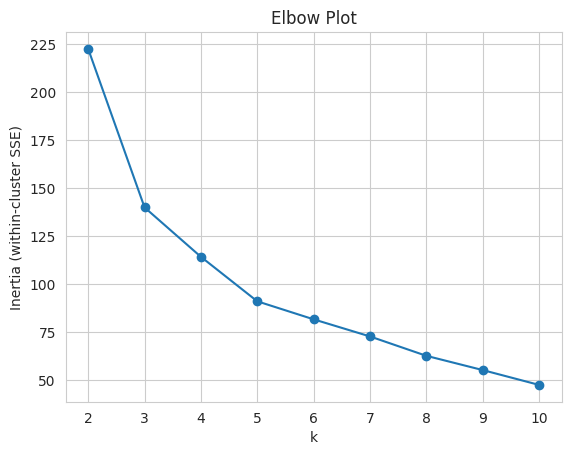

In [43]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# Choose k using elbow + silhouette
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot elbow (inertia)
plt.figure()
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot")
plt.show()

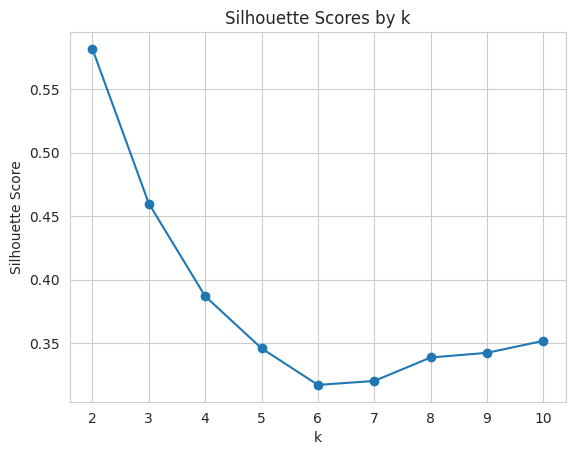

In [44]:
# Plot silhouette
plt.figure()
plt.plot(list(k_values), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by k")
plt.show()

In [45]:
best_k = int(list(k_values)[int(np.argmax(silhouettes))])
print(f"Best k by silhouette: {best_k} (silhouette={max(silhouettes):.4f})")

# Fit final KMeans
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
X_df["Cluster"] = cluster_labels

# Cluster centers (back to original units)
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=["Feature_1", "Feature_2", "Feature_3", "Feature_4"])
centers_df["Cluster"] = range(best_k)

print("\nCluster sizes:")
print(X_df["Cluster"].value_counts().sort_index())

print("\nCluster centers (original units):")
print(centers_df)

print("\nCluster profile (mean of each feature by cluster):")
print(X_df.groupby("Cluster")[["Feature_1", "Feature_2", "Feature_3", "Feature_4"]].mean())

Best k by silhouette: 2 (silhouette=0.5818)

Cluster sizes:
Cluster
0    100
1     50
Name: count, dtype: int64

Cluster centers (original units):
   Feature_1  Feature_2  Feature_3  Feature_4  Cluster
0      6.262      2.872      4.906      1.676        0
1      5.006      3.428      1.462      0.246        1

Cluster profile (mean of each feature by cluster):
         Feature_1  Feature_2  Feature_3  Feature_4
Cluster                                            
0            6.262      2.872      4.906      1.676
1            5.006      3.428      1.462      0.246


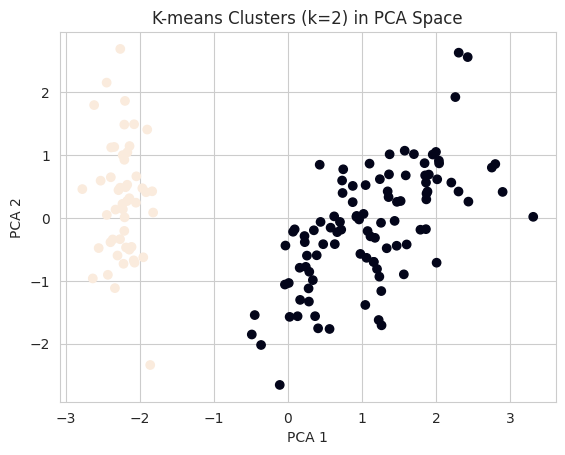

In [46]:
# PCA visualization in 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"K-means Clusters (k={best_k}) in PCA Space")
plt.show()


# Task 3: Regression

In [55]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import (
    RepeatedKFold, KFold, GridSearchCV, train_test_split, cross_val_score, cross_val_predict
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42

In [56]:
# 1) Load data
df3 = pd.read_csv("/content/Task3_Data_Process.csv")   # or "/mnt/data/Task3_Data_Process.csv"
assert {"x", "y"}.issubset(df3.columns), "CSV must contain columns: x, y"

X = df3[["x"]].values
y = df3["y"].values

print("Data shape:", df3.shape)
print(df3.head())

Data shape: (25, 2)
          x         y
0  0.287578  1.164440
1  0.788305 -0.887802
2  0.408977  0.174131
3  0.883017 -0.217437
4  0.940467 -0.076454


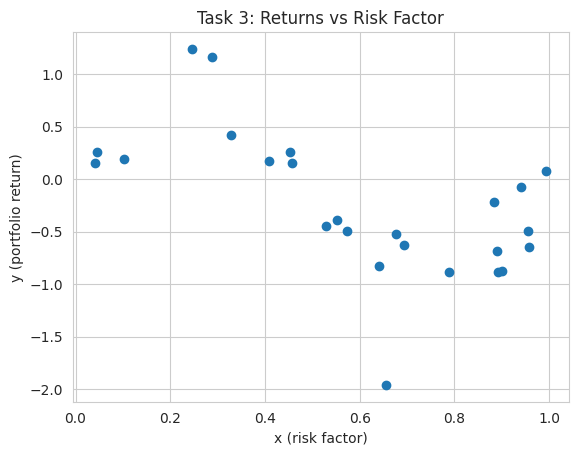

In [57]:
# 2) Visualize raw relationship
plt.figure()
plt.scatter(df3["x"], df3["y"])
plt.xlabel("x (risk factor)")
plt.ylabel("y (portfolio return)")
plt.title("Task 3: Returns vs Risk Factor")
plt.show()

In [58]:
# 3) Model: PolynomialFeatures + Ridge (tuned)
base_model = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("ridge", Ridge())
])

param_grid = {
    "poly__degree": [2, 3, 4, 5, 6, 7, 8],
    "ridge__alpha": np.logspace(-4, 3, 8)  # 1e-4 ... 1e3
}

# Repeated CV for more stable selection (small dataset)
rkf = RepeatedKFold(n_splits=5, n_repeats=20, random_state=RANDOM_STATE)

# Use MSE for selection (true RMSE behavior, not LOOCV artifact)
gs = GridSearchCV(
    base_model,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=rkf
)
gs.fit(X, y)

cvres = pd.DataFrame(gs.cv_results_)
cvres["mse_mean"] = -cvres["mean_test_score"]
cvres["mse_std"]  = cvres["std_test_score"]
cvres["rmse_mean"] = np.sqrt(cvres["mse_mean"])

best_row = cvres.loc[cvres["mse_mean"].idxmin()]
best_mse = best_row["mse_mean"]
best_std = best_row["mse_std"]

In [59]:
# 4) Anti-overfit rule: choose the LOWEST degree within (best_mse + best_std)
cvres["degree"] = cvres["param_poly__degree"].astype(int)
cvres["alpha"]  = cvres["param_ridge__alpha"].astype(float)

candidates = cvres[cvres["mse_mean"] <= best_mse + best_std].copy()
candidates = candidates.sort_values(["degree", "rmse_mean", "alpha"]).reset_index(drop=True)

chosen = candidates.iloc[0]
chosen_degree = int(chosen["degree"])
chosen_alpha  = float(chosen["alpha"])

print("\nSelected model (CV-tuned, anti-overfit rule):")
print(f"  degree = {chosen_degree}")
print(f"  alpha  = {chosen_alpha}")

final_model = Pipeline([
    ("poly", PolynomialFeatures(degree=chosen_degree, include_bias=False)),
    ("ridge", Ridge(alpha=chosen_alpha))
])


Selected model (CV-tuned, anti-overfit rule):
  degree = 3
  alpha  = 0.0001


In [60]:
# 5) Report CV metrics (5-fold once, for clean “mean±std” reporting)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mse_scores = -cross_val_score(final_model, X, y, cv=kf, scoring="neg_mean_squared_error")
rmse_scores = np.sqrt(mse_scores)
mae_scores = -cross_val_score(final_model, X, y, cv=kf, scoring="neg_mean_absolute_error")
r2_scores  =  cross_val_score(final_model, X, y, cv=kf, scoring="r2")

print("\n5-fold CV metrics (mean ± std):")
print(f"  RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"  MAE : {mae_scores.mean():.4f} ± {mae_scores.std():.4f}")
print(f"  R^2 : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")


5-fold CV metrics (mean ± std):
  RMSE: 0.4023 ± 0.1612
  MAE : 0.3173 ± 0.1190
  R^2 : 0.2329 ± 0.5257


In [61]:
# 6) Optional: hold-out test metrics (for a “train/test” statement)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
test_rmse = math.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("\nHold-out test metrics (80/20 split):")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE : {test_mae:.4f}")
print(f"  R^2 : {test_r2:.4f}")



Hold-out test metrics (80/20 split):
  RMSE: 0.4937
  MAE : 0.4077
  R^2 : 0.3956


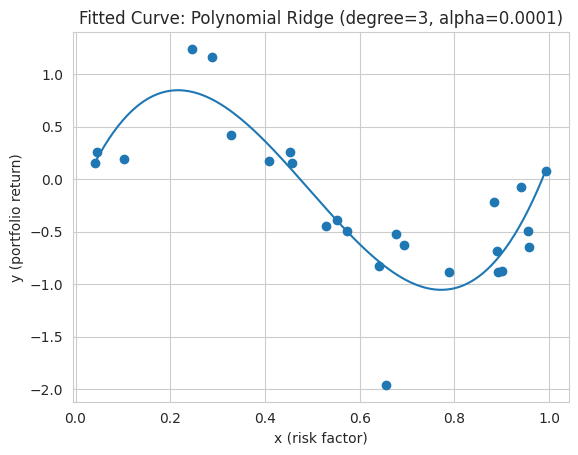

In [62]:
# 7) Fit on ALL data + plot fitted curve
final_model.fit(X, y)
x_grid = np.linspace(df3["x"].min(), df3["x"].max(), 300).reshape(-1, 1)
y_grid = final_model.predict(x_grid)

plt.figure()
plt.scatter(df3["x"], df3["y"])
plt.plot(x_grid.ravel(), y_grid)
plt.xlabel("x (risk factor)")
plt.ylabel("y (portfolio return)")
plt.title(f"Fitted Curve: Polynomial Ridge (degree={chosen_degree}, alpha={chosen_alpha:g})")
plt.show()


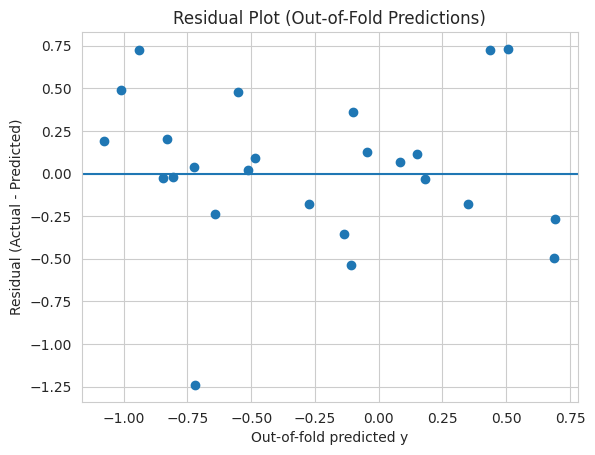


Underlying trend statement (use in report):
  Returns increase at low risk (x) to a positive region, then fall sharply in the mid-range,
  and show partial recovery toward higher x values — indicating a non-linear relationship.


In [63]:
# 8) Residual plot using out-of-fold predictions (single 5-fold CV)
y_oof = cross_val_predict(final_model, X, y, cv=kf)
residuals = y - y_oof

plt.figure()
plt.scatter(y_oof, residuals)
plt.axhline(0)
plt.xlabel("Out-of-fold predicted y")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Out-of-Fold Predictions)")
plt.show()

print("\nUnderlying trend statement (use in report):")
print("  Returns increase at low risk (x) to a positive region, then fall sharply in the mid-range,")
print("  and show partial recovery toward higher x values — indicating a non-linear relationship.")